# Oil Palm Disease Classification using ALOS-2 SAR

**Postgraduate Research** — Prerequisites & Environment Setup

This notebook sets up the full environment for processing ALOS-2 PALSAR-2 data on **Google Colab**:
- **ESA SNAP 13.0.0** (Sentinel Toolboxes) — SAR processing engine
- **esa_snappy** — Python bridge to SNAP's Java API
- **Scientific Python stack** — numpy, rasterio, scikit-learn, etc.

Persistent storage uses **Google Cloud Storage** (SNAP binary cached in a bucket to avoid re-downloading on each session).

---

## Prerequisites

### 0. Authenticate GCS & Set Project Root

**Before running**: create a GCS bucket at https://console.cloud.google.com/storage and
set `GCS_BUCKET` below to your bucket name.

SNAP (~1.5 GB) will be cached in `gs://<bucket>/snap/` so it only needs to be downloaded from ESA once.

In [2]:
from google.colab import auth
auth.authenticate_user()

# --- CONFIGURE THESE ---
GCS_BUCKET = "sar-oilpalm"          # your GCS bucket name (no gs://)
PROJECT_ROOT = "/content/SAR-OilPalm"  # local working dir on Colab VM
# -----------------------

import os
os.makedirs(f"{PROJECT_ROOT}/data", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/snap", exist_ok=True)
os.chdir(PROJECT_ROOT)

print(f"GCS bucket: gs://{GCS_BUCKET}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {os.getcwd()}")

# Verify GCS access
!gsutil ls "gs://{GCS_BUCKET}" > /dev/null 2>&1 && echo "GCS access OK" || echo "GCS access FAILED — check bucket name and permissions"

GCS bucket: gs://sar-oilpalm
Project root: /content/SAR-OilPalm
Working directory: /content/SAR-OilPalm
GCS access OK


### 1. System Setup — Python Dependencies

Installs `uv`, then installs all Python packages to the Colab system Python via `uv pip install --system`.

In [2]:
# System checks
import platform, sys, shutil, os
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.machine()}")
print(f"Python: {sys.version}")
print(f"wget: {shutil.which('wget') or 'not found'}")
print(f"curl: {shutil.which('curl') or 'not found'}")
print(f"java: {shutil.which('java') or 'not found (SNAP bundles its own JRE)'}")

Platform: Linux 6.6.122+
Architecture: x86_64
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
wget: /usr/bin/wget
curl: /usr/bin/curl
java: /usr/bin/java


In [3]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
cd "$PROJECT_ROOT"

echo "Installing uv..."
pip install uv -q
echo "uv: $(uv --version)"

echo "Installing packages to Colab system Python..."
uv pip install --system \
    esa-snappy \
    "numpy>=1.26" scipy \
    matplotlib seaborn \
    rasterio rioxarray \
    geopandas shapely pyproj \
    scikit-learn \
    jupyter ipykernel ipywidgets \
    tqdm joblib

echo ""
echo "=== Environment ready ==="
python --version

Installing uv...
uv: uv 0.11.29 (x86_64-unknown-linux-gnu)
Installing packages to Colab system Python...

=== Environment ready ===
Python 3.12.13


Using Python 3.12.13 environment at: /usr
Checked 16 packages in 246ms


### 2. Download & Install ESA SNAP 13.0.0

Restores SNAP from the GCS cache if available, otherwise downloads the installer from ESA,
installs it, and caches the result on GCS for future sessions.

In [4]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
GCS_BUCKET="sar-oilpalm"
SNAP_HOME="$PROJECT_ROOT/snap"
INSTALLER="esa-snap_sentinel_linux-13.0.0.sh"
INSTALLER_URL="https://download.esa.int/step/snap/13.0/installers/${INSTALLER}"
GCS_SNAP_CACHE="gs://$GCS_BUCKET/snap-13.0.0.tar.gz"

# Check if SNAP is already installed locally
if [ -f "$SNAP_HOME/bin/snap" ]; then
    echo "SNAP already installed at $SNAP_HOME — skipping"
    ls -la "$SNAP_HOME/bin/" | head -5
    exit 0
fi

restore_from_cache() {
    echo "Restoring SNAP from GCS cache..."
    gsutil cp "$GCS_SNAP_CACHE" - | tar xzf - -C "$PROJECT_ROOT"
    echo "SNAP restored to $SNAP_HOME"
    return 0
}

# Try restoring from GCS cache first
if gsutil -q stat "$GCS_SNAP_CACHE" 2>/dev/null; then
    restore_from_cache
    exit 0
fi

echo "No GCS cache found — downloading from ESA..."

# Download installer (cache the installer on GCS too)
GCS_INSTALLER_CACHE="gs://$GCS_BUCKET/installers/$INSTALLER"
if gsutil -q stat "$GCS_INSTALLER_CACHE" 2>/dev/null; then
    echo "Downloading installer from GCS cache..."
    gsutil cp "$GCS_INSTALLER_CACHE" "$INSTALLER"
else
    echo "Downloading installer from ESA (~1 GB)..."
    wget "$INSTALLER_URL" -O "$INSTALLER"
    gsutil cp "$INSTALLER" "$GCS_INSTALLER_CACHE"
fi
chmod +x "$INSTALLER"
echo "Installer ready: $(du -h $INSTALLER | cut -f1)"

# Create response file for quiet headless install
cat > response.varfile << 'EOF'
sys.adminRights$Boolean=false
sys.component.RSTB$Boolean=true
sys.component.S1TBX$Boolean=true
sys.component.S2TBX$Boolean=true
sys.component.S3TBX$Boolean=false
sys.component.SNAP$Boolean=true
sys.installationDir=__SNAP_HOME__
sys.languageId=en
sys.programGroupDisabled$Boolean=true
createDesktopLinkAction$Boolean=false
executeLauncherWithPythonAction$Boolean=false
deleteSnapDir$Boolean=false
EOF
sed -i "s|__SNAP_HOME__|$SNAP_HOME|" response.varfile

# Run installer in quiet mode
mkdir -p "$SNAP_HOME"
echo "Installing SNAP to $SNAP_HOME (this may take a few minutes)..."
bash "$INSTALLER" -q -varfile response.varfile
echo "SNAP installation complete"

# Cache the installed SNAP on GCS for next session
echo "Caching SNAP installation on GCS..."
tar czf /tmp/snap-13.0.0.tar.gz -C "$PROJECT_ROOT" snap
gsutil cp /tmp/snap-13.0.0.tar.gz "$GCS_SNAP_CACHE"
rm -f /tmp/snap-13.0.0.tar.gz
echo "SNAP cached at $GCS_SNAP_CACHE"

ls -la "$SNAP_HOME/bin/" | head -5

SNAP already installed at /content/SAR-OilPalm/snap — skipping
total 104
drwxr-xr-x  2 root root  4096 Jul 15 08:32 .
drwxr-xr-x 12 root root  4096 Jul 15 08:32 ..
-rwxr-xr-x  1 root root 13800 Oct 29  2025 gpt
-rw-r--r--  1 root root   250 Jul 15 08:32 gpt.vmoptions


### 3. Configure esa_snappy (SNAP ↔ Python Bridge)

Connects SNAP's Java engine to the Colab system Python.

In [5]:
%%bash
set -e

PROJECT_ROOT="/content/SAR-OilPalm"
SNAP_HOME="$PROJECT_ROOT/snap"

export PATH="$SNAP_HOME/bin:$PATH"

echo "=== Running snappy-conf ==="
"$SNAP_HOME/bin/snappy-conf" "$(which python)"

echo ""
echo "=== GPT CLI ==="
"$SNAP_HOME/bin/gpt" -h 2>&1 | head -8 || true

echo ""
echo "=== Setup Complete ==="

=== Running snappy-conf ===
Configuring ESA SNAP-Python interface...
Found esa_snappy installed in '/usr/local/lib/python3.12/dist-packages'
Starting configuration...
Configuration finished successful!
Done. The SNAP-Python interface is located in '/usr/local/lib/python3.12/dist-packages/esa_snappy'
The executable of the Python environment is located at '/usr/local/bin/python'

=== GPT CLI ===
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
Usage:
  gpt <op>|<graph-file> [options] [<source-file-1> <source-file-2> ...]

Description:
  This tool is used to execute SNAP raster data operators in batch-mode. The
  operators can be used stand-alone or combined as a directed acyclic graph

=== Setup Complete ===


OpenJDK 64-Bit Server VM warning: Options -Xverify:none and -noverify were deprecated in JDK 13 and will likely be removed in a future release.


In [6]:
import esa_snappy
from esa_snappy import ProductIO, GPF
print('OK - esa_snappy is configured and ready')

OK - esa_snappy is configured and ready


### 4. Quick Test

Verifies the full pipeline — `esa_snappy` imports and SNAP GPT CLI.

In [7]:
print('esa_snappy is ready for ALOS-2 SAR processing')
ops = GPF.getDefaultInstance().getOperatorSpiRegistry().getOperatorSpis()
print(f'Available operators: {ops.size()}')

esa_snappy is ready for ALOS-2 SAR processing
Available operators: 156


---
## Extraction of SAR BackScatter Intensity
- From the SHP file, identify the tree's coords (Lat, Long) then extract the dB (HH, VV, VH) from scene files.
- Since the SAR scene resolution might not be enough, any trees within the same resolution cell share the same dB of backscatter
- From the csv file, merge the health status to its responding tree based on coords

_SAR scene_ located at: `gs://$GCS_BUCKET/data/SAR-scenes`\
The SAR scene folder contains one or more `<scene>.data` folder and `<scene>.dim`.

_SHP zip_ located at: `gs://$GCS_BUCKET/data/SHP-files`\
The SHP zip contains files that are named by its location, `<location>.cpg/.dbf/.prj/.qmd/.shp/.shx`

_Label csv zip_ located at: `gs://$GCS_BUCKET/data/Label-status`\
The Label zip contains files that are named by its location aswell, `<location>.csv/.cpg/.dbf/.prj/.qmd/.shp/.shx`

### 5. Configuration & Data Download

Single ALOS-2 PALSAR-2 scene (fully polarimetric, `Cal_ML_Spk_TC` preprocessed) covers both Palong and Serting sites. Tree centroids, labels, and the SAR scene are downloaded from GCS if not cached locally.

In [3]:
import os
import glob

GCS_BUCKET  = "sar-oilpalm"
SCENE_NAME  = "ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC"

DATA_DIR     = f"{PROJECT_ROOT}/data"
SCENE_DIR    = f"{DATA_DIR}/SAR-scenes"
OUTPUT_DIR   = f"{DATA_DIR}/processed"

LOCAL_DIM_PATH     = f"{SCENE_DIR}/{SCENE_NAME}.dim"
LOCAL_GEOTIFF_PATH = f"{SCENE_DIR}/{SCENE_NAME}_dB.tif"

LOCATIONS = ["Palong_Basemap", "Serting_Basemap"]

for d in [SCENE_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Download SHP + Label zips from GCS (gcloud storage CLI, replaces gsutil) ---
# The zips may extract to a different folder name than expected (e.g., Result/
# instead of Label_Palong2022/), so we glob for the actual CSV/SHP afterwards.
for subdir, zip_name in [("SHP-files", "SHP_Palong2022.zip"),
                         ("Label-status", "Label_Palong2022.zip")]:
    extracted_root = f"{DATA_DIR}/{subdir}"
    already_there = glob.glob(f"{extracted_root}/**/*Classification.csv", recursive=True) \
                    + glob.glob(f"{extracted_root}/**/*centroid.shp", recursive=True)
    if already_there:
        print(f"[OK] {subdir} already extracted ({len(already_there)} files found)")
        continue
    os.makedirs(extracted_root, exist_ok=True)
    gcs_path  = f"gs://{GCS_BUCKET}/data/{subdir}/{zip_name}"
    local_zip = f"{extracted_root}/{zip_name}"
    print(f"Downloading {zip_name} from GCS via gcloud storage...")
    !gcloud storage cp "{gcs_path}" "{local_zip}"
    !unzip -q -o "{local_zip}" -d "{extracted_root}"
    if os.path.exists(local_zip):
        os.remove(local_zip)
    print(f"  -> extracted to {extracted_root}")

# --- Locate label folder dynamically ---
# Zip may extract to Label_Palong2022/, Result/, or directly. Glob handles all cases.
LABEL_DIR = None
for location in LOCATIONS:
    matches = glob.glob(
        f"{DATA_DIR}/Label-status/**/{location} Classification.csv",
        recursive=True
    )
    if matches:
        LABEL_DIR = os.path.dirname(matches[0])
        break
if LABEL_DIR is None:
    raise FileNotFoundError(
        f"Could not find any '<location> Classification.csv' under {DATA_DIR}/Label-status/. "
        f"Check that the zip extracted correctly."
    )
print(f"Label folder (LABEL_DIR): {LABEL_DIR}")

# --- Locate SHP folder dynamically (kept for future use; not required for dB extraction) ---
SHP_DIR = None
for location in LOCATIONS:
    matches = glob.glob(
        f"{DATA_DIR}/SHP-files/**/{location}*.shp",
        recursive=True
    )
    if matches:
        SHP_DIR = os.path.dirname(matches[0])
        break
print(f"SHP folder   (SHP_DIR):   {SHP_DIR or '(not found)'}")

# --- Download SAR scene from GCS ---
if not os.path.exists(LOCAL_DIM_PATH):
    gcs_prefix = f"gs://{GCS_BUCKET}/data/SAR-scenes/{SCENE_NAME}"
    print(f"\nDownloading SAR scene from GCS via gcloud storage (may take a while)...")
    !gcloud storage cp -r "{gcs_prefix}*" "{SCENE_DIR}/"
    print(f"  -> {SCENE_DIR}")
else:
    print(f"\n[OK] SAR scene already present")

print(f"\n=== Config ===")
print(f"Scene:     {SCENE_NAME}")
print(f"Locations: {LOCATIONS}")
print(f"GeoTIFF:   {LOCAL_GEOTIFF_PATH}")
print(f"Output:    {OUTPUT_DIR}")

[OK] SHP-files already extracted (2 files found)
[OK] Label-status already extracted (2 files found)
Label folder (LABEL_DIR): /content/SAR-OilPalm/data/Label-status/Result
SHP folder   (SHP_DIR):   /content/SAR-OilPalm/data/SHP-files

[OK] SAR scene already present

=== Config ===
Scene:     ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC
Locations: ['Palong_Basemap', 'Serting_Basemap']
GeoTIFF:   /content/SAR-OilPalm/data/SAR-scenes/ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC_dB.tif
Output:    /content/SAR-OilPalm/data/processed


### 6. Inspect SAR Scene

Read the `.dim` product with `esa_snappy`, list available bands, and detect whether values are in linear or dB scale.

In [4]:
from esa_snappy import ProductIO
import numpy as np

product = ProductIO.readProduct(LOCAL_DIM_PATH)
band_names = list(product.getBandNames())
print(f"Product: {product.getName()}")
print(f"Bands ({len(band_names)}):")
for bn in band_names:
    print(f"  - {bn}")

# Map band names to polarization
def extract_pol(name):
    u = name.upper()
    for pol in ['HH', 'HV', 'VV', 'VH']:
        if pol in u:
            return pol
    return None

pol_bands = {}
for name in band_names:
    pol = extract_pol(name)
    if pol and pol not in pol_bands:
        pol_bands[pol] = name

POL_ORDER = ['HH', 'HV', 'VV', 'VH']
available_pols = [p for p in POL_ORDER if p in pol_bands]
print(f"\nPolarizations found: {available_pols}")
print(f"Band mapping: {pol_bands}")

# Sample from the CENTER of the scene (borders are often zero-padded in TC products)
def read_sample_region(band, x0, y0, sw, sh):
    buf = np.zeros(sw * sh, dtype=np.float32)
    band.readPixels(x0, y0, sw, sh, buf)
    return buf.reshape(sh, sw)

sample_band = product.getBand(band_names[0])
w, h = sample_band.getRasterWidth(), sample_band.getRasterHeight()
sw, sh = min(500, w), min(500, h)
x0 = max(0, (w - sw) // 2)
y0 = max(0, (h - sh) // 2)

sample = read_sample_region(sample_band, x0, y0, sw, sh)
valid = sample[sample != 0]

# Fallback: if center is all zero, try 3 random regions (deterministic seed)
if len(valid) == 0:
    print(f"\nCenter region is all zero -- sampling 3 random regions as fallback")
    rng = np.random.default_rng(42)
    all_vals = []
    rs = 300
    for _ in range(3):
        rx = int(rng.integers(0, max(1, w - rs)))
        ry = int(rng.integers(0, max(1, h - rs)))
        s = read_sample_region(sample_band, rx, ry, rs, rs)
        all_vals.extend(s[s != 0].tolist())
    valid = np.array(all_vals) if all_vals else np.array([])

if len(valid) > 0:
    vmin, vmax, vmean = valid.min(), valid.max(), valid.mean()
    has_negative = vmin < 0
    print(f"\nSample stats ({band_names[0]}):")
    print(f"  n_valid={len(valid)}  min={vmin:.4f}  max={vmax:.4f}  mean={vmean:.4f}")
    print(f"  has_negative={has_negative}")

    # Better heuristic: dB has negative values; linear sigma0 is always >= 0
    if has_negative:
        is_db = True
        scale_label = "dB (has negative values -- no conversion needed)"
    elif vmax < 1.0 and vmean < 0.5:
        is_db = False
        scale_label = "Linear (all positive, max < 1.0 -- will convert to dB)"
    else:
        # Ambiguous: max >= 1 and no negatives. Could be linear with strong scatterers
        # or already-dB with a very bright target. Default to linear (safer to convert
        # than to skip conversion on truly linear data).
        is_db = False
        scale_label = "Linear (no negatives, max >= 1.0 -- assuming linear, will convert)"
    print(f"  Detected scale: {scale_label}")
else:
    print(f"\nERROR: All sampled pixels are zero across center + 3 random regions.")
    print(f"       Scene may be corrupted or bands are stored differently than expected.")
    is_db = False  # conservative default

product.dispose()

Product: ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC
Bands (8):
  - Sigma0_HH
  - Sigma0_HV
  - Sigma0_VH
  - Sigma0_VV
  - Sigma0_HH_db
  - Sigma0_HV_db
  - Sigma0_VH_db
  - Sigma0_VV_db

Polarizations found: ['HH', 'HV', 'VV', 'VH']
Band mapping: {'HH': 'Sigma0_HH', 'HV': 'Sigma0_HV', 'VH': 'Sigma0_VH', 'VV': 'Sigma0_VV'}

Sample stats (Sigma0_HH):
  n_valid=250000  min=0.0134  max=7.2559  mean=0.1657
  has_negative=False
  Detected scale: Linear (no negatives, max >= 1.0 -- assuming linear, will convert)


### 7. Export to GeoTIFF (SNAP GPT)

Build a GPT graph that:
1. Reads the `.dim` product
2. Selects only HH, HV, VV, VH bands (`BandSelect`)
3. Converts linear sigma0 -> dB via `LinearToFromdB` (skipped if already in dB)
4. Writes a stacked GeoTIFF for efficient point sampling with `rasterio`

In [5]:
import subprocess

FORCE_REEXPORT = False  # Set True to force re-export even if GeoTIFF exists

if os.path.exists(LOCAL_GEOTIFF_PATH) and not FORCE_REEXPORT:
    print(f"[OK] GeoTIFF already exists: {LOCAL_GEOTIFF_PATH}")
    print("     (Set FORCE_REEXPORT=True to re-export)")
else:
    selected_band_names = [pol_bands[p] for p in available_pols]
    band_list_str = ",".join(selected_band_names)

    read_node = f"""  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters>
      <file>{LOCAL_DIM_PATH}</file>
    </parameters>
  </node>"""

    select_node = f"""  <node id="BandSelect">
    <operator>BandSelect</operator>
    <sources>
      <sourceProduct refid="Read"/>
    </sources>
    <parameters>
      <sourceBands>{band_list_str}</sourceBands>
    </parameters>
  </node>"""

    if is_db:
        last_ref = "BandSelect"
        db_node = ""
    else:
        last_ref = "ToDB"
        db_node = f"""
  <node id="ToDB">
    <operator>LinearToFromdB</operator>
    <sources>
      <sourceProduct refid="BandSelect"/>
    </sources>
  </node>"""

    write_node = f"""  <node id="Write">
    <operator>Write</operator>
    <sources>
      <sourceProduct refid="{last_ref}"/>
    </sources>
    <parameters>
      <file>{LOCAL_GEOTIFF_PATH}</file>
      <formatName>GeoTIFF-BigTIFF</formatName>
    </parameters>
  </node>"""

    graph_xml = f"""<graph id="sar_to_db_geotiff">
  <version>1.0</version>
{read_node}
{select_node}
{db_node}
{write_node}
</graph>"""

    graph_path = f"{SCENE_DIR}/sar_to_db.xml"
    with open(graph_path, 'w') as f:
        f.write(graph_xml)
    print(f"Graph written to {graph_path}")
    print(f"\n--- Graph XML ---\n{graph_xml}")

    # Run GPT
    gpt_bin = f"{PROJECT_ROOT}/snap/bin/gpt"
    env = os.environ.copy()
    env['SNAP_HOME'] = f"{PROJECT_ROOT}/snap"
    env['PATH'] = f"{PROJECT_ROOT}/snap/bin:{env.get('PATH', '')}"

    print(f"\nRunning GPT (this may take a few minutes)...")
    result = subprocess.run(
        [gpt_bin, graph_path],
        capture_output=True, text=True, env=env
    )
    print(f"Exit code: {result.returncode}")
    if result.stdout:
        print(f"stdout (last 500 chars):\n{result.stdout[-500:]}")
    if result.stderr:
        print(f"stderr (last 500 chars):\n{result.stderr[-500:]}")

    if result.returncode != 0:
        raise RuntimeError(f"GPT failed with exit code {result.returncode}")

    size_mb = os.path.getsize(LOCAL_GEOTIFF_PATH) / (1024 * 1024)
    print(f"\n[OK] GeoTIFF created: {LOCAL_GEOTIFF_PATH} ({size_mb:.1f} MB)")

[OK] GeoTIFF already exists: /content/SAR-OilPalm/data/SAR-scenes/ALOS2-HBQR1_1__D-ORBIT__ALOS2650583560-260610_Cal_ML_Spk_TC_dB.tif
     (Set FORCE_REEXPORT=True to re-export)


### 8. Sample dB at Tree Coordinates & Build Dataset

For each tree `(id, Long, Lat)` in the label CSVs:
1. Reproject WGS-84 -> scene CRS (UTM) via `rasterio.warp.transform`
2. Sample the GeoTIFF at the reprojected coordinate
3. Trees in the same SAR resolution cell share the same dB value automatically
4. Compute `HHHVRatio = HH_dB - HV_dB` (dB difference, physically meaningful)
5. Map `Class` -> `Health` (1:1), set `Tier = 0` (placeholder int)

> **Note**: "Middle" class trees are **retained** in the dataset CSV. They will be
> filtered out during TabFM modeling:
> ```python
> df_tabfm = df[df['Health'].isin(['Healthy', 'Unhealthy'])].copy()
> ```

In [6]:
import rasterio
from rasterio.warp import transform as warp_transform
import pandas as pd
import numpy as np

src = rasterio.open(LOCAL_GEOTIFF_PATH)
print(f"GeoTIFF CRS:    {src.crs}")
print(f"Bands:          {src.count}")
print(f"Size:           {src.width} x {src.height}")
print(f"Resolution:     {src.res}")
print(f"Nodata:         {src.nodata}")
print(f"Band desc:      {list(src.descriptions)}")

# GeoTIFF band order matches available_pols from inspection cell
print(f"Expected pols:  {available_pols}")

datasets = {}
for location in LOCATIONS:
    csv_path = f"{LABEL_DIR}/{location} Classification.csv"
    # csv_path = '/content/SAR-OilPalm/data/Label-status/Result/Palong_Basemap Classification.csv'  # Hardcoded fix, TODO update to be more robust, and for other locations
    df = pd.read_csv(csv_path)
    print(f"\n--- {location} ({len(df)} trees) ---")

    # Reproject tree coords: EPSG:4326 (WGS-84) -> scene CRS
    xs_scene, ys_scene = warp_transform(
        "EPSG:4326", src.crs,
        df['Long'].values.tolist(),
        df['Lat'].values.tolist()
    )

    # Sample GeoTIFF at tree coordinates
    coord_pairs = list(zip(xs_scene, ys_scene))
    samples = np.array(list(src.sample(coord_pairs)), dtype=float)

    # Replace nodata with NaN
    if src.nodata is not None:
        samples[samples == src.nodata] = np.nan
    samples[samples <= -99] = np.nan  # common SNAP nodata sentinel

    # Assign polarization values (band order = available_pols)
    for i, pol in enumerate(available_pols):
        df[pol] = samples[:, i]

    # Compute HHHVRatio = HH_dB - HV_dB (dB difference)
    if 'HH' in df.columns and 'HV' in df.columns:
        df['HHHVRatio'] = df['HH'] - df['HV']
    else:
        df['HHHVRatio'] = np.nan

    # Health from Class (1:1; Middle RETAINED for now -- filtered at TabFM stage)
    df['Health'] = df['Class']

    # Tier = 0 (placeholder int; will become 0-3 when more training data arrives)
    df['Tier'] = 0

    # Select final column order (VH kept for reference per user request)
    final_cols = ['id', 'Long', 'Lat', 'HH', 'HV', 'VV', 'VH', 'HHHVRatio', 'Health', 'Tier']
    final_cols = [c for c in final_cols if c in df.columns]
    final_df = df[final_cols].copy()
    datasets[location] = final_df

    # Report
    valid = final_df['HH'].notna()
    n_valid = valid.sum()
    n_nan = (~valid).sum()
    print(f"  Valid dB:          {n_valid}/{len(final_df)}")
    print(f"  NaN (out of scene): {n_nan}")
    print(f"  Class distribution: {final_df['Health'].value_counts().to_dict()}")
    for pol in ['HH', 'HV', 'VV', 'VH']:
        if pol in final_df.columns:
            vals = final_df[pol].dropna()
            if len(vals) > 0:
                print(f"  {pol} dB: mean={vals.mean():.2f}, range=[{vals.min():.2f}, {vals.max():.2f}]")

src.close()
print("\nDatasets built for:", list(datasets.keys()))

GeoTIFF CRS:    EPSG:32648
Bands:          4
Size:           8437 x 11862
Resolution:     (6.4301092, 6.4301092)
Nodata:         None
Band desc:      [None, None, None, None]
Expected pols:  ['HH', 'HV', 'VV', 'VH']

--- Palong_Basemap (2664 trees) ---
  Valid dB:          2664/2664
  NaN (out of scene): 0
  Class distribution: {'Healthy': 1971, 'Middle': 493, 'Unhealthy': 200}
  HH dB: mean=-8.60, range=[-13.44, 0.59]
  HV dB: mean=-16.76, range=[-21.86, -11.31]
  VV dB: mean=-10.26, range=[-15.06, 1.25]
  VH dB: mean=-16.70, range=[-21.45, -10.51]

--- Serting_Basemap (2045 trees) ---
  Valid dB:          2045/2045
  NaN (out of scene): 0
  Class distribution: {'Healthy': 1513, 'Middle': 378, 'Unhealthy': 154}
  HH dB: mean=-7.98, range=[-11.94, -3.03]
  HV dB: mean=-16.60, range=[-20.46, -12.58]
  VV dB: mean=-10.14, range=[-13.29, -3.13]
  VH dB: mean=-16.63, range=[-20.00, -11.85]

Datasets built for: ['Palong_Basemap', 'Serting_Basemap']


### 9. Write Dataset CSVs & Sanity Checks

In [7]:
# Write per-location dataset CSVs
for location, df in datasets.items():
    output_path = f"{OUTPUT_DIR}/dataset_{location}.csv"
    df.to_csv(output_path, index=False)
    print(f"Wrote {output_path} ({len(df)} rows)")

# --- Sanity checks ---
print("\n=== Sanity Checks ===")
all_pass = True
for location, df in datasets.items():
    print(f"\n--- {location} ---")

    # Check 1: Row count matches label CSV
    label_csv = f"{LABEL_DIR}/{location} Classification.csv"
    # label_csv = '/content/SAR-OilPalm/data/Label-status/Result/Palong_Basemap Classification.csv'  # Hardcoded fix, TODO update to be more robust, and for other locations
    label_count = len(pd.read_csv(label_csv))
    assert len(df) == label_count, f"Row count mismatch: {len(df)} vs {label_count}"
    print(f"  [PASS] Row count matches label CSV ({len(df)})")

    # Check 2: At least some trees have valid dB
    valid_count = df['HH'].notna().sum()
    if valid_count == 0:
        print(f"  [FAIL] No trees have valid dB values")
        all_pass = False
    else:
        print(f"  [PASS] {valid_count} trees have valid dB")

    # Check 3: HHHVRatio in reasonable range
    ratio = df['HHHVRatio'].dropna()
    if len(ratio) > 0:
        if ratio.between(-20, 20).all():
            print(f"  [PASS] HHHVRatio in [-20, 20] dB (range: {ratio.min():.2f} to {ratio.max():.2f})")
        else:
            print(f"  [WARN] HHHVRatio outside [-20, 20]: min={ratio.min():.2f}, max={ratio.max():.2f}")

    # Check 4: HH-HV correlation
    mask = df['HH'].notna() & df['HV'].notna()
    if mask.sum() > 10:
        corr = df.loc[mask, 'HH'].corr(df.loc[mask, 'HV'])
        print(f"  [INFO] HH-HV correlation: {corr:.3f}")

    # Check 5: Preview
    print(f"  Preview:")
    print(df.head(3).to_string(index=False))

print(f"\n{'='*50}")
print(f"Overall: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")

Wrote /content/SAR-OilPalm/data/processed/dataset_Palong_Basemap.csv (2664 rows)
Wrote /content/SAR-OilPalm/data/processed/dataset_Serting_Basemap.csv (2045 rows)

=== Sanity Checks ===

--- Palong_Basemap ---
  [PASS] Row count matches label CSV (2664)
  [PASS] 2664 trees have valid dB
  [PASS] HHHVRatio in [-20, 20] dB (range: 1.81 to 15.21)
  [INFO] HH-HV correlation: 0.491
  Preview:
 id       Long      Lat        HH         HV         VV         VH  HHHVRatio  Health  Tier
  1 102.667295 2.745769 -7.477726 -17.782179 -12.048995 -18.905622  10.304453 Healthy     0
  2 102.667299 2.745832 -8.050183 -16.386950 -11.074947 -17.450722   8.336766 Healthy     0
  3 102.667304 2.745916 -7.834494 -15.593040  -8.852572 -15.589664   7.758546 Healthy     0

--- Serting_Basemap ---
  [PASS] Row count matches label CSV (2045)
  [PASS] 2045 trees have valid dB
  [PASS] HHHVRatio in [-20, 20] dB (range: 3.05 to 14.48)
  [INFO] HH-HV correlation: 0.120
  Preview:
 id       Long      Lat        HH  

### 10. Visual QA

Plots to verify data quality:
1. Tree locations colored by HH dB (per location)
2. dB distributions per polarization
3. HH vs HV scatter (colored by Health)
4. Class distribution per location
5. HHHVRatio distribution by Health class

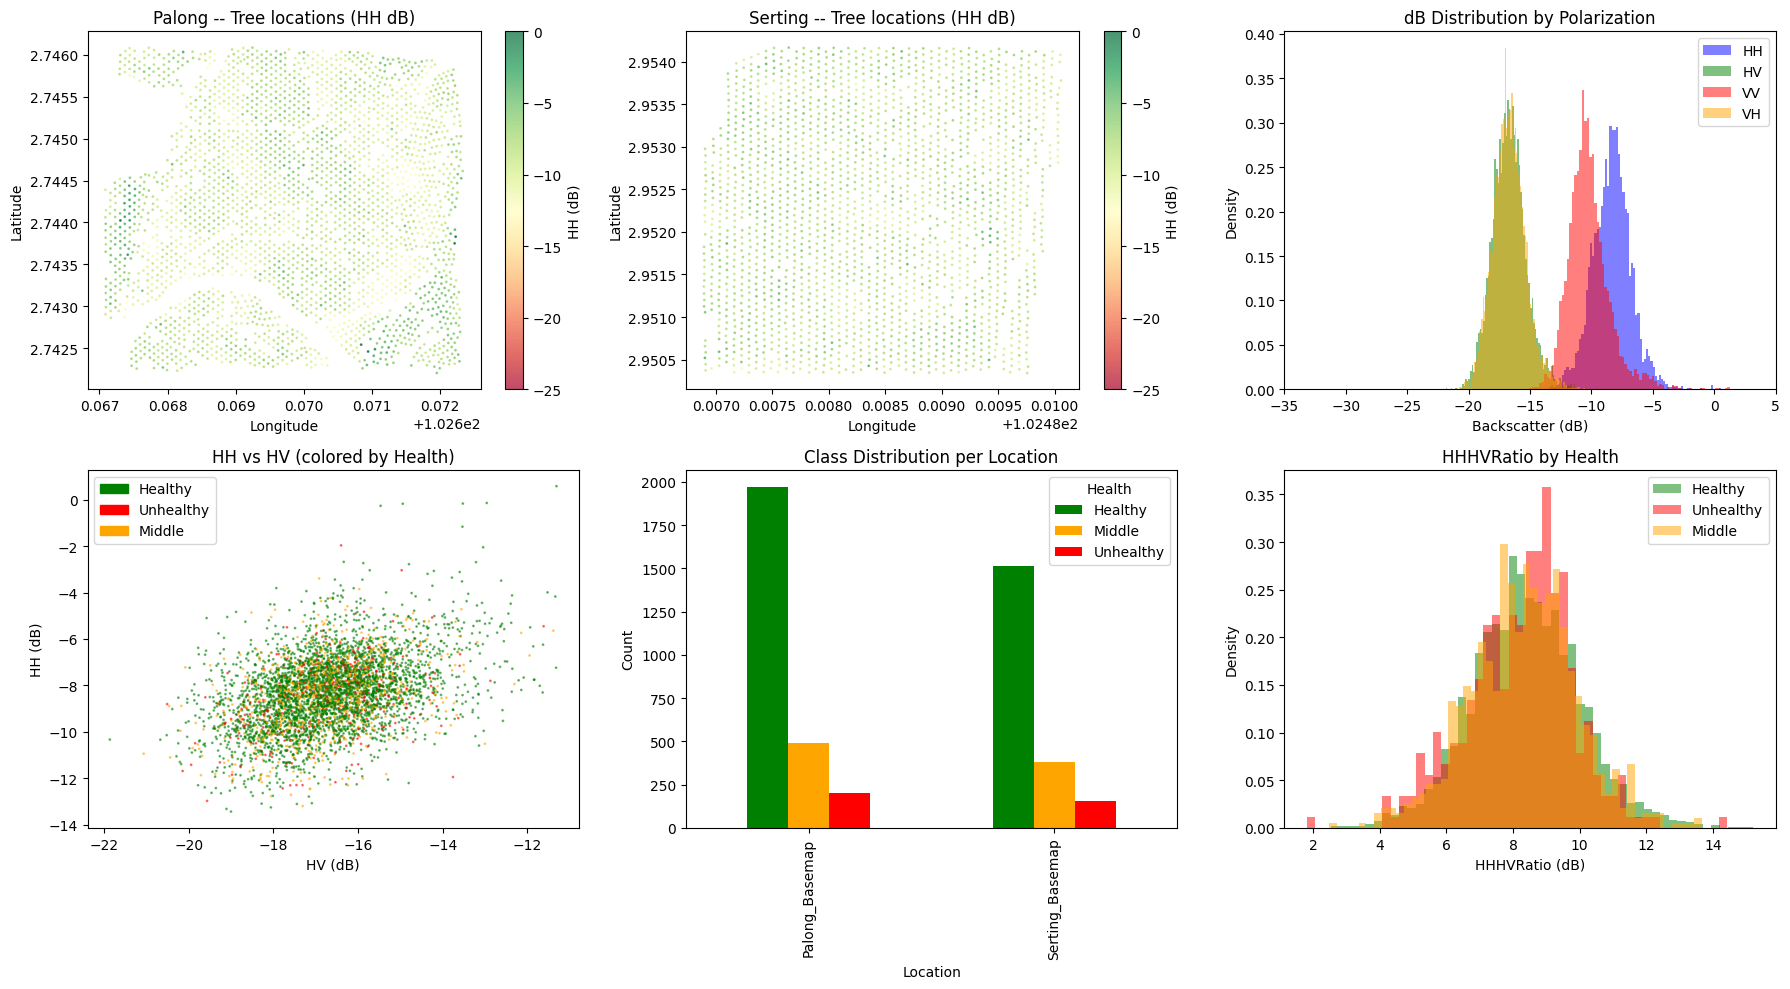

Visual QA saved to /content/SAR-OilPalm/data/processed/visual_qa.png


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

combined = pd.concat(
    [df.assign(Location=loc) for loc, df in datasets.items()],
    ignore_index=True
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
HEALTH_COLORS = {'Healthy': 'green', 'Unhealthy': 'red', 'Middle': 'orange'}

# --- Plot 1: Palong tree locations (HH dB) ---
ax = axes[0, 0]
df_p = datasets['Palong_Basemap']
sc = ax.scatter(df_p['Long'], df_p['Lat'], c=df_p['HH'],
                cmap='RdYlGn', s=1, alpha=0.7, vmin=-25, vmax=0)
plt.colorbar(sc, ax=ax, label='HH (dB)')
ax.set_title('Palong -- Tree locations (HH dB)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# --- Plot 2: Serting tree locations (HH dB) ---
ax = axes[0, 1]
df_s = datasets['Serting_Basemap']
sc = ax.scatter(df_s['Long'], df_s['Lat'], c=df_s['HH'],
                cmap='RdYlGn', s=1, alpha=0.7, vmin=-25, vmax=0)
plt.colorbar(sc, ax=ax, label='HH (dB)')
ax.set_title('Serting -- Tree locations (HH dB)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# --- Plot 3: dB distributions ---
ax = axes[0, 2]
for pol, color in [('HH', 'blue'), ('HV', 'green'), ('VV', 'red'), ('VH', 'orange')]:
    if pol in combined.columns:
        vals = combined[pol].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=80, alpha=0.5, label=pol, color=color, density=True)
ax.set_xlabel('Backscatter (dB)')
ax.set_ylabel('Density')
ax.set_title('dB Distribution by Polarization')
ax.legend()
ax.set_xlim(-35, 5)

# --- Plot 4: HH vs HV scatter ---
ax = axes[1, 0]
valid = combined['HH'].notna() & combined['HV'].notna()
colors = combined.loc[valid, 'Health'].map(HEALTH_COLORS).fillna('gray')
ax.scatter(combined.loc[valid, 'HV'], combined.loc[valid, 'HH'],
           c=colors, s=1, alpha=0.5)
ax.set_xlabel('HV (dB)')
ax.set_ylabel('HH (dB)')
ax.set_title('HH vs HV (colored by Health)')
ax.legend(handles=[Patch(color=c, label=l) for l, c in HEALTH_COLORS.items()],
          markerscale=5)

# --- Plot 5: Class distribution per location ---
ax = axes[1, 1]
class_counts = combined.groupby(['Location', 'Health']).size().unstack(fill_value=0)
class_counts.plot(kind='bar', ax=ax,
                  color=[HEALTH_COLORS.get(c, 'gray') for c in class_counts.columns])
ax.set_title('Class Distribution per Location')
ax.set_xlabel('Location'); ax.set_ylabel('Count')
ax.legend(title='Health')

# --- Plot 6: HHHVRatio by Health class ---
ax = axes[1, 2]
for cls, color in HEALTH_COLORS.items():
    vals = combined.loc[combined['Health'] == cls, 'HHHVRatio'].dropna()
    if len(vals) > 0:
        ax.hist(vals, bins=50, alpha=0.5, label=cls, color=color, density=True)
ax.set_xlabel('HHHVRatio (dB)')
ax.set_ylabel('Density')
ax.set_title('HHHVRatio by Health')
ax.legend()

plt.tight_layout()
qa_path = f"{OUTPUT_DIR}/visual_qa.png"
plt.savefig(qa_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Visual QA saved to {qa_path}")

---
## Datasets Preparation

Dataset CSVs are ready at `data/processed/dataset_<location>.csv`.

**Schema**: `id, Long, Lat, HH, HV, VV, VH, HHHVRatio, Health, Tier`

**Pipeline** (all steps consolidated):

| Step | Action |
|------|--------|
| 1 | Load Palong + Serting CSVs, add `Location` feature |
| 2 | Filter out `Middle` class → binary Healthy/Unhealthy |
| 3 | Drop `id, Long, Lat, VH, Tier` → features: `HH, HV, VV, HHHVRatio, Location` |
| 4 | Encode: `Health` (0=Healthy, 1=Unhealthy), `Location` (one-hot) |
| 5 | Stratified 80:20 hold-out split (stratify by `Health`) |
| 6 | Setup Repeated Stratified 5-fold CV (3 repeats = 15 folds) for robust evaluation |
| Summary | Print per-class stats, per-location breakdown, feature statistics |

**Design decisions**:
> Middle class is dropped for ALL 3 models to ensure comparability. SMOTE and Z-score scaling are NOT applied globally here — they go inside CV 
pipelines (Shared Evaluation Harness) to prevent data leakage.

In [9]:
import pandas as pd
import numpy as np

# -- Load & Concatenate --
palong = pd.read_csv(f"{OUTPUT_DIR}/dataset_Palong_Basemap.csv")
serting = pd.read_csv(f"{OUTPUT_DIR}/dataset_Serting_Basemap.csv")

palong['Location'] = 'Palong'
serting['Location'] = 'Serting'
df = pd.concat([palong, serting], ignore_index=True)

print(f"Loaded: Palong={len(palong)} trees, Serting={len(serting)} trees")
print(f"Combined: {len(df)} trees")
print(f"\nFull class distribution:\n{df['Health'].value_counts()}")

# -- Drop Middle (binary classification: Healthy vs Unhealthy) --
df = df[df['Health'] != 'Middle'].copy()
print(f"\n--- After dropping Middle: {len(df)} trees ---")
print(f"Class distribution:\n{df['Health'].value_counts()}")

# -- Feature selection --
drop_cols = ['id', 'Long', 'Lat', 'VH', 'Tier', 'Health']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode target: Unhealthy = 1 (positive class for disease detection)
y = (df['Health'] == 'Unhealthy').astype(int)

# One-hot encode Location (drop first to avoid collinearity)
X = pd.get_dummies(X, columns=['Location'], drop_first=True)
feature_names = X.columns.tolist()

print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"Target: 0=Healthy ({sum(y==0)}), 1=Unhealthy ({sum(y==1)})")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Store global seed for reproducibility
RANDOM_STATE = 42

Loaded: Palong=2664 trees, Serting=2045 trees
Combined: 4709 trees

Full class distribution:
Health
Healthy      3484
Middle        871
Unhealthy     354
Name: count, dtype: int64

--- After dropping Middle: 3838 trees ---
Class distribution:
Health
Healthy      3484
Unhealthy     354
Name: count, dtype: int64

Features (5): ['HH', 'HV', 'VV', 'HHHVRatio', 'Location_Serting']
Target: 0=Healthy (3484), 1=Unhealthy (354)
X shape: (3838, 5), y shape: (3838,)


In [10]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"=== Hold-out Split (80:20, stratified) ===")
print(f"Train: {X_train.shape[0]} samples")
print(f"  Healthy={sum(y_train==0)}, Unhealthy={sum(y_train==1)}, ratio={sum(y_train==0)/max(sum(y_train==1),1):.1f}:1")
print(f"Test:  {X_test.shape[0]} samples")
print(f"  Healthy={sum(y_test==0)}, Unhealthy={sum(y_test==1)}, ratio={sum(y_test==0)/max(sum(y_test==1),1):.1f}:1")

=== Hold-out Split (80:20, stratified) ===
Train: 3070 samples
  Healthy=2787, Unhealthy=283, ratio=9.8:1
Test:  768 samples
  Healthy=697, Unhealthy=71, ratio=9.8:1


In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold

CV_FOLDS = 5
CV_REPEATS = 3

cv = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE
)

print(f"CV setup: {CV_FOLDS} folds x {CV_REPEATS} repeats = {CV_FOLDS * CV_REPEATS} total splits")

# -- Dataset Summary --
print("\n" + "=" * 55)
print("                 DATASET SUMMARY")
print("=" * 55)
print(f"Total samples:        {len(y)}")
print(f"Healthy:              {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"Unhealthy:            {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")
print(f"Imbalance ratio:      {sum(y==0)/max(sum(y==1),1):.1f}:1")
print(f"Features:             {len(feature_names)}")
for fn in feature_names:
    print(f"  \u2022 {fn}")
print(f"\nPer-location breakdown:")
for loc in ['Palong', 'Serting']:
    n_h = sum((df['Location'] == loc) & (df['Health'] == 'Healthy'))
    n_u = sum((df['Location'] == loc) & (df['Health'] == 'Unhealthy'))
    print(f"  {loc}: {n_h} Healthy, {n_u} Unhealthy (total: {n_h + n_u})")
print(f"\nFeature statistics (mean by class):")
for feat in ['HH', 'HV', 'VV', 'HHHVRatio']:
    if feat in X.columns:
        print(f"  {feat}: Healthy={X.loc[y==0, feat].mean():.2f}, Unhealthy={X.loc[y==1, feat].mean():.2f}")
print("=" * 55)

CV setup: 5 folds x 3 repeats = 15 total splits

                 DATASET SUMMARY
Total samples:        3838
Healthy:              3484 (90.8%)
Unhealthy:            354 (9.2%)
Imbalance ratio:      9.8:1
Features:             5
  • HH
  • HV
  • VV
  • HHHVRatio
  • Location_Serting

Per-location breakdown:
  Palong: 1971 Healthy, 200 Unhealthy (total: 2171)
  Serting: 1513 Healthy, 154 Unhealthy (total: 1667)

Feature statistics (mean by class):
  HH: Healthy=-8.28, Unhealthy=-8.51
  HV: Healthy=-16.67, Unhealthy=-16.72
  VV: Healthy=-10.15, Unhealthy=-10.42
  HHHVRatio: Healthy=8.39, Unhealthy=8.21


---
## Shared Evaluation Harness

Defines the evaluation infrastructure that ALL 3 ML classifiers call. This ensures **comparability by construction**:

- **Identical metrics** for all models
- **Identical CV folds** (RepeatedStratifiedKFold, 5 folds x 3 repeats)
- **Pipeline abstraction** with optional SMOTE and Z-score scaling (applied INSIDE CV to prevent data leakage)
- **4 configs per model**: baseline, +SMOTE, tuned/ensemble, tuned+SMOTE

> **Tree models (RF/XGB) are scale-invariant** → scaling disabled. **TabFM uses attention with Fourier features** → scaling enabled.

In [12]:
import time
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, cohen_kappa_score, brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImblearnPipeline
from imblearn.over_sampling import SMOTE

# -- Paths --
RESULTS_DIR = f"{OUTPUT_DIR}/results"
PLOTS_DIR = f"{RESULTS_DIR}/plots"
MODELS_DIR = f"{OUTPUT_DIR}/models"
for d in [RESULTS_DIR, PLOTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# -- Constants --
SMOTE_K_NEIGHBORS = 5

METRIC_NAMES = [
    'accuracy', 'balanced_accuracy', 'precision', 'recall',
    'f1_binary', 'f1_macro', 'roc_auc', 'pr_auc', 'cohen_kappa',
    'brier_score', 'runtime_train_s', 'runtime_pred_s',
    'tn', 'fp', 'fn', 'tp'
]

def compute_metrics(y_true, y_pred, y_proba, train_time=0.0, pred_time=0.0):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    if y_proba.ndim == 1:
        pos_proba = y_proba
    else:
        pos_proba = y_proba[:, 1]

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_binary': f1_score(y_true, y_pred, zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'roc_auc': roc_auc_score(y_true, pos_proba),
        'pr_auc': average_precision_score(y_true, pos_proba),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'brier_score': brier_score_loss(y_true, pos_proba),
        'runtime_train_s': train_time,
        'runtime_pred_s': pred_time,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

print("Harness config & metrics ready.")

Harness config & metrics ready.


In [13]:
def build_pipeline(model, use_smote=False, use_scaling=False):
    steps = []
    if use_scaling:
        steps.append(('scaler', StandardScaler()))
    if use_smote:
        steps.append(('smote', SMOTE(
            k_neighbors=SMOTE_K_NEIGHBORS, random_state=RANDOM_STATE
        )))
    steps.append(('model', model))
    return ImblearnPipeline(steps)


def eval_holdout(pipeline, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    pipeline.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)
    pred_time = time.time() - t0

    return compute_metrics(y_te, y_pred, y_proba, train_time, pred_time)


def eval_cv(pipeline_factory):
    results = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        pipeline = pipeline_factory()

        t0 = time.time()
        pipeline.fit(X_tr, y_tr)
        train_time = time.time() - t0

        t0 = time.time()
        y_pred = pipeline.predict(X_te)
        y_proba = pipeline.predict_proba(X_te)
        pred_time = time.time() - t0

        m = compute_metrics(y_te, y_pred, y_proba, train_time, pred_time)
        m['fold'] = fold_idx
        results.append(m)
    return pd.DataFrame(results)


def save_results(result_df, model_name, eval_type):
    path = f"{RESULTS_DIR}/{model_name}_{eval_type}.csv"
    if isinstance(result_df, dict):
        result_df = pd.DataFrame([result_df])
    result_df.to_csv(path, index=False)
    print(f"  Saved: {path}")
    return path


def cv_summary_df(cv_df):
    score_cols = [c for c in METRIC_NAMES if c in cv_df.columns]
    mean = cv_df[score_cols].mean()
    std = cv_df[score_cols].std()
    return {f"{col}_mean": mean[col] for col in score_cols} | \
           {f"{col}_std": std[col] for col in score_cols}


print("Pipeline, eval & save helpers ready.")

Pipeline, eval & save helpers ready.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})
HEALTH_COLORS = {'Healthy': 'green', 'Unhealthy': 'red'}


def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy (0)', 'Unhealthy (1)'],
                yticklabels=['Healthy (0)', 'Unhealthy (1)'])
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')


def plot_roc_curve(fpr, tpr, auc_val, label, ax):
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc_val:.3f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])


def plot_pr_curve(prec, rec, ap_val, label, baseline, ax):
    ax.plot(rec, prec, label=f'{label} (AP={ap_val:.3f})', linewidth=2)
    ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.3,
               label=f'No skill ({baseline:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curves')
    ax.legend(loc='lower left', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])


def plot_roc_pr_for_model(pipeline, X_tr, y_tr, X_te, y_te, config_label, ax_roc, ax_pr):
    """Fit pipeline and plot ROC + PR curves on test set."""
    from sklearn.metrics import roc_curve, precision_recall_curve
    pipeline.fit(X_tr, y_tr)
    y_proba = pipeline.predict_proba(X_te)
    if y_proba.ndim == 1:
        pos_proba = y_proba
    else:
        pos_proba = y_proba[:, 1]

    fpr, tpr, _ = roc_curve(y_te, pos_proba)
    roc_auc = roc_auc_score(y_te, pos_proba)
    prec, rec, _ = precision_recall_curve(y_te, pos_proba)
    pr_auc = average_precision_score(y_te, pos_proba)
    baseline_val = sum(y_te == 1) / len(y_te)

    plot_roc_curve(fpr, tpr, roc_auc, config_label, ax_roc)
    plot_pr_curve(prec, rec, pr_auc, config_label, baseline_val, ax_pr)


print("Plotting helpers ready.")

Plotting helpers ready.


---
## ML1 -- Random Forest

**Algorithm family**: Bagging ensemble of decision trees with random feature subspaces.

**Why chosen**: Strong tabular baseline — handles non-linear interactions natively, scale-invariant (no preprocessing needed), interpretable via feature importance. `class_weight='balanced'` handles the ~10:1 class imbalance.

**Configs evaluated**:
| Config | Description |
|--------|-------------|
| `default_baseline` | Default hyperparams + class_weight='balanced' |
| `default_smote`    | Default + SMOTE inside CV pipeline |
| `tuned_baseline`   | GridSearchCV best params + class_weight='balanced' |
| `tuned_smote`      | GridSearchCV best params + SMOTE |

**Hyperparameter search space**:
- `n_estimators`: [100, 300, 500]
- `max_depth`: [None, 10, 20, 30]
- `min_samples_split`: [2, 5, 10]
- `max_features`: ['sqrt', 'log2']

In [20]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest classifier ready.")

Random Forest classifier ready.


In [21]:
from sklearn.model_selection import GridSearchCV

# -- Hyperparameter Tuning (GridSearch, inner 3-fold CV) --
print("Tuning Random Forest via GridSearchCV ...")
rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

RF_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_gs = GridSearchCV(
    rf_base, RF_PARAM_GRID, cv=3, scoring='f1_macro', n_jobs=-1
)
rf_gs.fit(X_train, y_train)

rf_best_params = rf_gs.best_params_
print(f"Best params: {rf_best_params}")
print(f"Best CV f1_macro: {rf_gs.best_score_:.4f}")

# -- Model factories --
def make_rf_default():
    return RandomForestClassifier(
        n_estimators=500, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )

def make_rf_tuned():
    return RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        **rf_best_params
    )

# -- Run 4 configs --
rf_configs = [
    ('default_baseline', make_rf_default, False, False),
    ('default_smote',    make_rf_default, True,  False),
    ('tuned_baseline',   make_rf_tuned,   False, False),
    ('tuned_smote',      make_rf_tuned,   True,  False),
]

rf_holdout = {}
rf_cv_all = []

for cfg_name, factory, use_smote, use_scaling in rf_configs:
    print(f"\n--- RF {cfg_name} ---")

    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    m = eval_holdout(pipe, X_train, y_train, X_test, y_test)
    m['config'] = cfg_name
    rf_holdout[cfg_name] = m

    print(f"  Holdout: ROC-AUC={m['roc_auc']:.4f}, F1-binary={m['f1_binary']:.4f}, "
          f"Recall={m['recall']:.4f}, train_time={m['runtime_train_s']:.1f}s")

    # Build cv pipeline factory (need unique context per fold)
    # Using default args with closure
    def _make_p(f=factory, sm=use_smote, sc=use_scaling):
        return build_pipeline(f(), use_smote=sm, use_scaling=sc)

    cv_df = eval_cv(_make_p)
    cv_df['config'] = cfg_name
    rf_cv_all.append(cv_df)

    cv_auc = cv_df['roc_auc'].mean()
    cv_auc_std = cv_df['roc_auc'].std()
    print(f"  CV:      ROC-AUC={cv_auc:.4f} \u00b1 {cv_auc_std:.4f}, "
          f"F1={cv_df['f1_binary'].mean():.4f} \u00b1 {cv_df['f1_binary'].std():.4f}")

# -- Save --
rf_holdout_df = pd.DataFrame(list(rf_holdout.values()))
rf_cv_df = pd.concat(rf_cv_all, ignore_index=True)
save_results(rf_holdout_df, 'rf', 'holdout')
save_results(rf_cv_df, 'rf', 'cv')
print("\n=== RF Complete ===")

Tuning Random Forest via GridSearchCV ...


Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Best CV f1_macro: 0.4930

--- RF default_baseline ---
  Holdout: ROC-AUC=0.5357, F1-binary=0.0000, Recall=0.0000, train_time=3.6s
  CV:      ROC-AUC=0.4920 ± 0.0226, F1=0.0000 ± 0.0000

--- RF default_smote ---
  Holdout: ROC-AUC=0.5140, F1-binary=0.1509, Recall=0.2254, train_time=7.3s
  CV:      ROC-AUC=0.4938 ± 0.0277, F1=0.1179 ± 0.0266

--- RF tuned_baseline ---
  Holdout: ROC-AUC=0.5824, F1-binary=0.1562, Recall=0.1408, train_time=0.6s
  CV:      ROC-AUC=0.5155 ± 0.0347, F1=0.0834 ± 0.0307

--- RF tuned_smote ---
  Holdout: ROC-AUC=0.5575, F1-binary=0.1618, Recall=0.3521, train_time=0.9s
  CV:      ROC-AUC=0.5148 ± 0.0344, F1=0.1430 ± 0.0246
  Saved: /content/SAR-OilPalm/data/processed/results/rf_holdout.csv
  Saved: /content/SAR-OilPalm/data/processed/results/rf_cv.csv

=== RF Complete ===


                   RANDOM FOREST RESULTS

--- Hold-out ---
          config  roc_auc   pr_auc  f1_binary  f1_macro  balanced_accuracy   recall  precision  runtime_train_s
default_baseline 0.535696 0.103658   0.000000  0.475051           0.498565 0.000000   0.000000         3.626089
   default_smote 0.513953 0.103363   0.150943  0.507496           0.523006 0.225352   0.113475         7.295351
  tuned_baseline 0.582355 0.121942   0.156250  0.539773           0.536707 0.140845   0.175439         0.572434
     tuned_smote 0.557500 0.114246   0.161812  0.475364           0.523259 0.352113   0.105042         0.900906

--- CV (mean ± std, 15 folds) ---

  [default_baseline]
    roc_auc: 0.4920 ± 0.0226
    pr_auc: 0.0930 ± 0.0073
    f1_binary: 0.0000 ± 0.0000
    f1_macro: 0.4753 ± 0.0005
    balanced_accuracy: 0.4989 ± 0.0009
    recall: 0.0000 ± 0.0000
    precision: 0.0000 ± 0.0000
    runtime_train_s: 3.9118 ± 0.6238

  [default_smote]
    roc_auc: 0.4938 ± 0.0277
    pr_auc: 0.0955 ± 0.

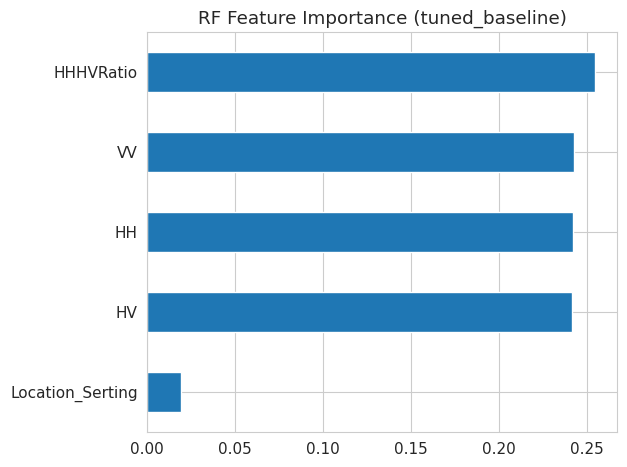

HHHVRatio           0.254483
VV                  0.242957
HH                  0.242093
HV                  0.241532
Location_Serting    0.018935

--- Confusion Matrix (best holdout config) ---


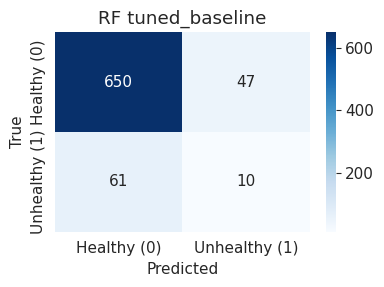

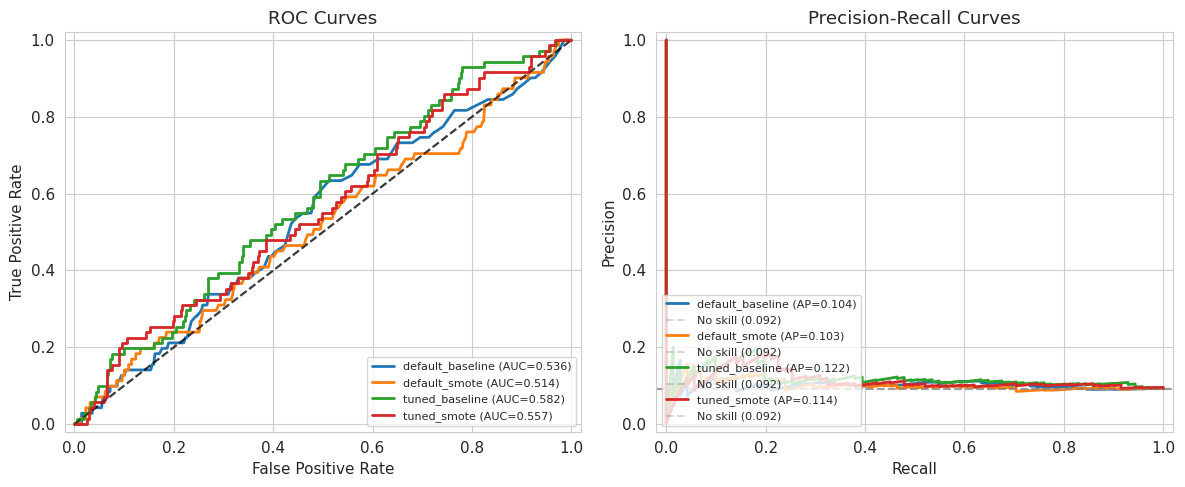


RF results & plots saved to results/


In [22]:
# -- RF Results Table --
DISPLAY = ['roc_auc', 'pr_auc', 'f1_binary', 'f1_macro', 'balanced_accuracy',
           'recall', 'precision', 'runtime_train_s']

print("=" * 90)
print("                   RANDOM FOREST RESULTS")
print("=" * 90)

rf_hold = pd.read_csv(f"{RESULTS_DIR}/rf_holdout.csv")
print("\n--- Hold-out ---")
print(rf_hold[['config'] + [c for c in DISPLAY if c in rf_hold.columns]].to_string(index=False))

rf_cv = pd.read_csv(f"{RESULTS_DIR}/rf_cv.csv")
score_cols = [c for c in DISPLAY if c in rf_cv.columns]
cv_agg = rf_cv.groupby('config')[score_cols].agg(['mean', 'std'])
print("\n--- CV (mean \u00b1 std, 15 folds) ---")
for cfg in cv_agg.index:
    print(f"\n  [{cfg}]")
    for col in score_cols:
        print(f"    {col}: {cv_agg.loc[cfg, (col, 'mean')]:.4f} \u00b1 {cv_agg.loc[cfg, (col, 'std')]:.4f}")

# Feature Importance from best model (by holdout ROC-AUC)
print("\n--- Feature Importance (best holdout config) ---")
best_cfg = rf_hold.sort_values('roc_auc', ascending=False).iloc[0]['config']
best_pipe = rf_gs.best_estimator_  # fitted tuned model
importances = pd.Series(best_pipe.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', title=f'RF Feature Importance ({best_cfg})')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(importances.sort_values(ascending=False).to_string())

print("\n--- Confusion Matrix (best holdout config) ---")
best_row = rf_hold[rf_hold['config'] == best_cfg].iloc[0]
cm = [[best_row['tn'], best_row['fp']],
      [best_row['fn'], best_row['tp']]]
fig, ax = plt.subplots(figsize=(4, 3))
plot_confusion_matrix(cm, f'RF {best_cfg}', ax)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/rf_confusion_{best_cfg}.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC & PR curves (all 4 configs)
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))
for cfg_name, factory, use_smote, use_scaling in rf_configs:
    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    plot_roc_pr_for_model(pipe, X_train, y_train, X_test, y_test,
                          cfg_name, ax_roc, ax_pr)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/rf_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nRF results & plots saved to results/")

---
## ML2 -- XGBoost

**Algorithm family**: Gradient-boosted decision trees with sequential error correction and L1/L2 regularization.

**Why chosen**: State-of-the-art for structured/tabular data. Different algorithmic paradigm from RF (boosting vs bagging) → meaningful comparison. Handles imbalance via `scale_pos_weight`, natively handles missing values.

**Configs evaluated**:
| Config | Description |
|--------|-------------|
| `default_baseline` | Default hyperparams + scale_pos_weight |
| `default_smote`    | Default + SMOTE inside CV pipeline |
| `tuned_baseline`   | GridSearchCV best params + scale_pos_weight |
| `tuned_smote`      | GridSearchCV best params + SMOTE |

**Hyperparameter search space**:
- `n_estimators`: [300], `max_depth`: [3, 6, 9]
- `learning_rate`: [0.05, 0.1, 0.2]
- `subsample`: [1.0], `colsample_bytree`: [0.8, 1.0]

In [23]:
import xgboost as xgb

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.3.0


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Imbalance ratio for scale_pos_weight
scale_weight = sum(y_train == 0) / max(sum(y_train == 1), 1)
print(f"scale_pos_weight: {scale_weight:.2f}")

# -- Hyperparameter Tuning --
print("\nTuning XGBoost via GridSearchCV ...")
xgb_base = XGBClassifier(
    device='cuda',
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=1
)

XGB_PARAM_GRID = {
    'n_estimators': [300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    xgb_base, XGB_PARAM_GRID, cv=3, scoring='f1_macro', n_jobs=-1
)
xgb_gs.fit(X_train, y_train)

xgb_best_params = xgb_gs.best_params_
print(f"Best params: {xgb_best_params}")
print(f"Best CV f1_macro: {xgb_gs.best_score_:.4f}")

# -- Model factories --
def make_xgb_default():
    return XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

def make_xgb_tuned():
    return XGBClassifier(
        scale_pos_weight=scale_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1,
        **xgb_best_params
    )

# -- Run 4 configs --
xgb_configs = [
    ('default_baseline', make_xgb_default, False, False),
    ('default_smote',    make_xgb_default, True,  False),
    ('tuned_baseline',   make_xgb_tuned,   False, False),
    ('tuned_smote',      make_xgb_tuned,   True,  False),
]

xgb_holdout = {}
xgb_cv_all = []

for cfg_name, factory, use_smote, use_scaling in xgb_configs:
    print(f"\n--- XGB {cfg_name} ---")

    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    m = eval_holdout(pipe, X_train, y_train, X_test, y_test)
    m['config'] = cfg_name
    xgb_holdout[cfg_name] = m

    print(f"  Holdout: ROC-AUC={m['roc_auc']:.4f}, F1={m['f1_binary']:.4f}, "
          f"Recall={m['recall']:.4f}, train_time={m['runtime_train_s']:.1f}s")

    def _make_p(f=factory, sm=use_smote, sc=use_scaling):
        return build_pipeline(f(), use_smote=sm, use_scaling=sc)

    cv_df = eval_cv(_make_p)
    cv_df['config'] = cfg_name
    xgb_cv_all.append(cv_df)

    cv_auc = cv_df['roc_auc'].mean()
    print(f"  CV:      ROC-AUC={cv_auc:.4f} \u00b1 {cv_df['roc_auc'].std():.4f}, "
          f"F1={cv_df['f1_binary'].mean():.4f} \u00b1 {cv_df['f1_binary'].std():.4f}")

# -- Save --
xgb_holdout_df = pd.DataFrame(list(xgb_holdout.values()))
xgb_cv_df = pd.concat(xgb_cv_all, ignore_index=True)
save_results(xgb_holdout_df, 'xgb', 'holdout')
save_results(xgb_cv_df, 'xgb', 'cv')
print("\n=== XGBoost Complete ===")

scale_pos_weight: 9.85

Tuning XGBoost via GridSearchCV ...
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
Best CV f1_macro: 0.4961

--- XGB default_baseline ---
  Holdout: ROC-AUC=0.5449, F1=0.0984, Recall=0.0845, train_time=0.4s
  CV:      ROC-AUC=0.4971 ± 0.0253, F1=0.0567 ± 0.0232

--- XGB default_smote ---
  Holdout: ROC-AUC=0.5163, F1=0.1641, Recall=0.4507, train_time=0.5s
  CV:      ROC-AUC=0.5031 ± 0.0301, F1=0.1472 ± 0.0174

--- XGB tuned_baseline ---
  Holdout: ROC-AUC=0.5529, F1=0.0921, Recall=0.0986, train_time=0.2s
  CV:      ROC-AUC=0.5097 ± 0.0247, F1=0.0961 ± 0.0287

--- XGB tuned_smote ---
  Holdout: ROC-AUC=0.5301, F1=0.1779, Recall=0.7465, train_time=0.3s
  CV:      ROC-AUC=0.5103 ± 0.0351, F1=0.1669 ± 0.0124
  Saved: /content/SAR-OilPalm/data/processed/results/xgb_holdout.csv
  Saved: /content/SAR-OilPalm/data/processed/results/xgb_cv.csv

=== XGBoost Complete ===


                   XGBOOST RESULTS

--- Hold-out ---
          config  roc_auc   pr_auc  f1_binary  f1_macro  balanced_accuracy   recall  precision  runtime_train_s
default_baseline 0.544931 0.108049   0.098361  0.510284           0.509972 0.084507   0.117647         0.438215
   default_smote 0.516317 0.100036   0.164103  0.439817           0.519470 0.450704   0.100313         0.538545
  tuned_baseline 0.552913 0.106847   0.092105  0.496197           0.496211 0.098592   0.086420         0.246185
     tuned_smote 0.530099 0.102060   0.177852  0.328288           0.534645 0.746479   0.100952         0.285131

--- CV (mean ± std, 15 folds) ---

  [default_baseline]
    roc_auc: 0.4971 ± 0.0253
    pr_auc: 0.0943 ± 0.0095
    f1_binary: 0.0567 ± 0.0232
    f1_macro: 0.4887 ± 0.0118
    balanced_accuracy: 0.4919 ± 0.0101
    recall: 0.0480 ± 0.0211
    precision: 0.0701 ± 0.0270
    runtime_train_s: 0.4293 ± 0.0153

  [default_smote]
    roc_auc: 0.5031 ± 0.0301
    pr_auc: 0.0954 ± 0.0127
 

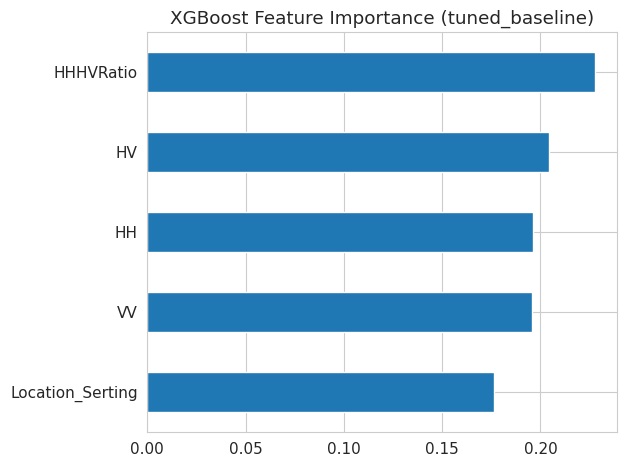

HHHVRatio           0.227547
HV                  0.204335
HH                  0.195942
VV                  0.195776
Location_Serting    0.176400

--- Confusion Matrix (best holdout config) ---


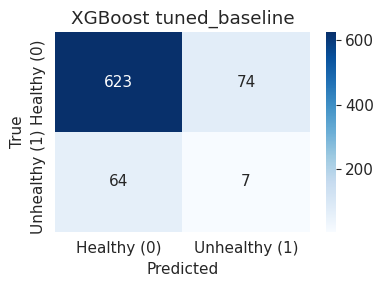

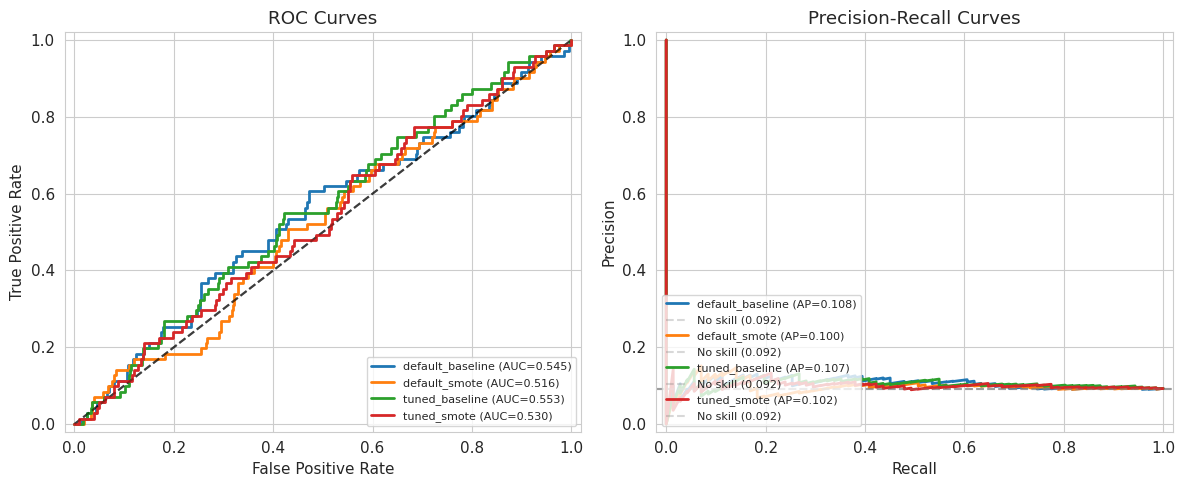


XGBoost results & plots saved to results/


In [25]:
# -- XGBoost Results Table --
DISPLAY = ['roc_auc', 'pr_auc', 'f1_binary', 'f1_macro', 'balanced_accuracy',
           'recall', 'precision', 'runtime_train_s']

print("=" * 90)
print("                   XGBOOST RESULTS")
print("=" * 90)

xgb_hold = pd.read_csv(f"{RESULTS_DIR}/xgb_holdout.csv")
print("\n--- Hold-out ---")
print(xgb_hold[['config'] + [c for c in DISPLAY if c in xgb_hold.columns]].to_string(index=False))

xgb_cv = pd.read_csv(f"{RESULTS_DIR}/xgb_cv.csv")
score_cols = [c for c in DISPLAY if c in xgb_cv.columns]
cv_agg = xgb_cv.groupby('config')[score_cols].agg(['mean', 'std'])
print("\n--- CV (mean \u00b1 std, 15 folds) ---")
for cfg in cv_agg.index:
    print(f"\n  [{cfg}]")
    for col in score_cols:
        print(f"    {col}: {cv_agg.loc[cfg, (col, 'mean')]:.4f} \u00b1 {cv_agg.loc[cfg, (col, 'std')]:.4f}")

# Feature Importance from best model (by holdout ROC-AUC)
print("\n--- Feature Importance (best holdout config, gain-based) ---")
best_cfg = xgb_hold.sort_values('roc_auc', ascending=False).iloc[0]['config']

# Fit best model to get feature importance
best_factory = make_xgb_tuned if 'tuned' in best_cfg else make_xgb_default
use_smote_fi = 'smote' in best_cfg
pipe_fi = build_pipeline(best_factory(), use_smote=use_smote_fi, use_scaling=False)
pipe_fi.fit(X_train, y_train)
importances = pd.Series(pipe_fi.named_steps['model'].feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', title=f'XGBoost Feature Importance ({best_cfg})')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/xgb_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(importances.sort_values(ascending=False).to_string())

# Confusion Matrix
print("\n--- Confusion Matrix (best holdout config) ---")
best_row = xgb_hold[xgb_hold['config'] == best_cfg].iloc[0]
cm = [[best_row['tn'], best_row['fp']],
      [best_row['fn'], best_row['tp']]]
fig, ax = plt.subplots(figsize=(4, 3))
plot_confusion_matrix(cm, f'XGBoost {best_cfg}', ax)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/xgb_confusion_{best_cfg}.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC & PR curves (all 4 configs)
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))
for cfg_name, factory, use_smote, use_scaling in xgb_configs:
    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    plot_roc_pr_for_model(pipe, X_train, y_train, X_test, y_test,
                          cfg_name, ax_roc, ax_pr)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/xgb_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nXGBoost results & plots saved to results/")

---
## ML3 -- TabFM (Foundation Model)

**Model**: Google Research's TabFM — a **zero-shot tabular foundation model** for classification and regression.

**Architecture**: Alternating column attention (Set Transformer) and row attention (RoPE) with a 24-block ICL transformer. Passes training rows as context; makes predictions in a single forward pass.

**Key difference from RF/XGBoost**: NO training required, NO hyperparameters to tune. The `ensemble()` preset (feature crosses + SVD features + NNLS blending) serves as this model's "boosted" counterpart (analogous to tuning for RF/XGBoost).

**Configs evaluated**:
| Config | Description |
|--------|-------------|
| `standard_baseline` | Standard TabFM classifier (zero-shot) |
| `standard_smote`    | Standard TabFM + SMOTE inside CV pipeline |
| `ensemble_baseline` | TabFM with ensemble() preset |
| `ensemble_smote`    | TabFM ensemble() + SMOTE |

**Scaling**: TabFM uses attention with Fourier features — Z-score scaling is applied (unlike tree models).
**License**: Non-commercial. **Reference**: [huggingface.co/google/tabfm-1.0.0-pytorch](https://huggingface.co/google/tabfm-1.0.0-pytorch)

In [17]:
!pip install "tabfm[pytorch] @ git+https://github.com/google-research/tabfm.git" --quiet

import os
import gc
import torch
from getpass import getpass

os.environ["HF_TOKEN"] = getpass("Enter your HF token (hf_...): ")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected. TabFM inference will be very slow on CPU.")
if device == "cuda":
    torch.cuda.set_per_process_memory_fraction(0.95)  # keep 30% buffer

from tabfm import TabFMClassifier, tabfm_v1_0_0_pytorch as tabfm_v1_0_0

model = tabfm_v1_0_0.load(model_type="classification", device=device)
print(f"TabFM model loaded on {device} (zero-shot, no training required)")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
TabFM model loaded on cuda (zero-shot, no training required)


In [18]:
def make_tabfm_standard():
    return TabFMClassifier(
        model=model, batch_size=512, cache_context=False
    )

def make_tabfm_ensemble():
    return TabFMClassifier.ensemble(
        model=model, batch_size=512, cache_context=False
    )

tabfm_configs = [
    ('standard_baseline', make_tabfm_standard, False, True),
    ('standard_smote',    make_tabfm_standard, True,  True),
    ('ensemble_baseline', make_tabfm_ensemble, False, True),
    ('ensemble_smote',    make_tabfm_ensemble, True,  True),
]

print("TabFM factories & configs ready (scaling=ON, batch_size=None, cache_context=True).")

gc.collect()
torch.cuda.empty_cache()
print("GPU memory cleared before TabFM inference.")

TabFM factories & configs ready (scaling=ON, batch_size=None, cache_context=True).
GPU memory cleared before TabFM inference.


In [ ]:
import time

tabfm_holdout = {}
tabfm_cv_all = []

for cfg_name, factory, use_smote, use_scaling in tabfm_configs:
    print(f"\n--- TabFM {cfg_name} ---")
    t_cfg = time.time()

    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    m = eval_holdout(pipe, X_train, y_train, X_test, y_test)
    m['config'] = cfg_name
    tabfm_holdout[cfg_name] = m

    del pipe
    gc.collect()
    torch.cuda.empty_cache()

    print(f"  Holdout: ROC-AUC={m['roc_auc']:.4f}, F1={m['f1_binary']:.4f}, "
          f"Recall={m['recall']:.4f}, train={m['runtime_train_s']:.1f}s, "
          f"pred={m['runtime_pred_s']:.1f}s")

    def _make_p(f=factory, sm=use_smote, sc=use_scaling):
        return build_pipeline(f(), use_smote=sm, use_scaling=sc)

    print(f"  Running CV (15 folds) ...")
    cv_results = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        t_fold = time.time()
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        p = _make_p()
        p.fit(X_tr, y_tr)
        y_p = p.predict(X_te)
        y_pr = p.predict_proba(X_te)

        fold_m = compute_metrics(y_te, y_p, y_pr, 0, 0)
        fold_m['fold'] = fold_idx
        cv_results.append(fold_m)

        del p
        gc.collect()
        torch.cuda.empty_cache()

        if fold_idx == 0:
            est = (time.time() - t_fold) * 15 / 60
            print(f"    Fold 0: {time.time()-t_fold:.1f}s (est. total: {est:.1f} min)")

    cv_df = pd.DataFrame(cv_results)
    cv_df['config'] = cfg_name
    tabfm_cv_all.append(cv_df)

    cv_auc = cv_df['roc_auc'].mean()
    print(f"  CV: ROC-AUC={cv_auc:.4f} ± {cv_df['roc_auc'].std():.4f}, "
          f"F1={cv_df['f1_binary'].mean():.4f}")
    print(f"  Config total: {time.time()-t_cfg:.1f}s")

    gc.collect()
    torch.cuda.empty_cache()

# -- Save --
tabfm_holdout_df = pd.DataFrame(list(tabfm_holdout.values()))
tabfm_cv_df = pd.concat(tabfm_cv_all, ignore_index=True)
save_results(tabfm_holdout_df, 'tabfm', 'holdout')
save_results(tabfm_cv_df, 'tabfm', 'cv')
print("\n=== TabFM Complete ===")


--- TabFM standard_baseline ---


OutOfMemoryError: CUDA out of memory. Tried to allocate 960.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.03 GiB is free. Including non-PyTorch memory, this process has 13.53 GiB memory in use. 13.84 GiB allowed; Of the allocated memory 11.80 GiB is allocated by PyTorch, and 1.60 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
# -- TabFM Results Table --
DISPLAY = ['roc_auc', 'pr_auc', 'f1_binary', 'f1_macro', 'balanced_accuracy',
           'recall', 'precision', 'runtime_train_s']

print("=" * 90)
print("                    TabFM RESULTS")
print("=" * 90)

tfm_hold = pd.read_csv(f"{RESULTS_DIR}/tabfm_holdout.csv")
print("\n--- Hold-out ---")
print(tfm_hold[['config'] + [c for c in DISPLAY if c in tfm_hold.columns]].to_string(index=False))

tfm_cv = pd.read_csv(f"{RESULTS_DIR}/tabfm_cv.csv")
score_cols = [c for c in DISPLAY if c in tfm_cv.columns]
cv_agg = tfm_cv.groupby('config')[score_cols].agg(['mean', 'std'])
print("\n--- CV (mean \u00b1 std, 15 folds) ---")
for cfg in cv_agg.index:
    print(f"\n  [{cfg}]")
    for col in score_cols:
        print(f"    {col}: {cv_agg.loc[cfg, (col, 'mean')]:.4f} \u00b1 {cv_agg.loc[cfg, (col, 'std')]:.4f}")

# ROC & PR curves (all 4 configs)
best_cfg = tfm_hold.sort_values('roc_auc', ascending=False).iloc[0]['config']

print(f"\n--- Confusion Matrix (best holdout config: {best_cfg}) ---")
best_row = tfm_hold[tfm_hold['config'] == best_cfg].iloc[0]
cm = [[best_row['tn'], best_row['fp']],
      [best_row['fn'], best_row['tp']]]
fig, ax = plt.subplots(figsize=(4, 3))
plot_confusion_matrix(cm, f'TabFM {best_cfg}', ax)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/tabfm_confusion_{best_cfg}.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC & PR curves overlay
print("\n--- ROC & PR Curves ---")
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))
for cfg_name, factory, use_smote, use_scaling in tabfm_configs:
    # Use smaller subset for faster curve plotting if needed
    pipe = build_pipeline(factory(), use_smote=use_smote, use_scaling=use_scaling)
    plot_roc_pr_for_model(pipe, X_train, y_train, X_test, y_test,
                          cfg_name, ax_roc, ax_pr)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/tabfm_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTabFM results & plots saved to results/")

---
## Benchmark Comparison

All results are loaded and compared side-by-side. Each of the 3 models was evaluated under 4 configs:

| Config | RF / XGBoost | TabFM |
|--------|-------------|-------|
| Out-of-box | `default_baseline` | `standard_baseline` |
| Out-of-box + SMOTE | `default_smote` | `standard_smote` |
| Best effort | `tuned_baseline` | `ensemble_baseline` |
| Best effort + SMOTE | `tuned_smote` | `ensemble_smote` |

**Metrics compared**: ROC-AUC, PR-AUC, F1 (binary macro), Balanced Accuracy, Recall, Precision.

**Statistical testing**: Pairwise Wilcoxon signed-rank test on CV fold scores (15 paired observations per model pair).

In [ ]:
def load_all_results():
    dfs = []
    for f in sorted(glob.glob(f"{RESULTS_DIR}/*.csv")):
        df_in = pd.read_csv(f)
        name = os.path.basename(f).replace('.csv', '')
        parts = name.rsplit('_', 1)
        if len(parts) == 2:
            df_in['model'] = parts[0]
            df_in['eval_type'] = parts[1]
            df_in['source_file'] = name
        dfs.append(df_in)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

all_results = load_all_results()
print(f"Loaded {len(all_results)} rows from {len(glob.glob(f'{RESULTS_DIR}/*.csv'))} CSV files")
print(f"Models: {sorted(all_results['model'].unique())}")
print(f"Eval types: {sorted(all_results['eval_type'].unique())}")
print(f"\nConfigs per model:")
print(all_results.groupby(['model', 'eval_type'])['config'].apply(list).to_string())

In [ ]:
METRIC_DISPLAY = ['roc_auc', 'pr_auc', 'f1_binary', 'f1_macro',
                  'balanced_accuracy', 'recall', 'precision',
                  'cohen_kappa', 'runtime_train_s']

holdout = all_results[all_results['eval_type'] == 'holdout'].copy()
cv_data = all_results[all_results['eval_type'] == 'cv'].copy()

# -- Hold-out Headline Table --
print("=" * 100)
print("              HEADLINE RESULTS -- Hold-out (80:20 stratified split)")
print("=" * 100)
available = [c for c in METRIC_DISPLAY if c in holdout.columns]
ht = holdout.set_index(['model', 'config'])[available].sort_index()
print(ht.round(4).to_string())
ht.round(4).to_csv(f"{RESULTS_DIR}/benchmark_holdout.csv")

# -- CV Summary Table --
if not cv_data.empty:
    print("\n" + "=" * 100)
    print("        CV RESULTS -- 5-fold x 3 repeats = 15 folds (mean \u00b1 std)")
    print("=" * 100)
    score_cols = [c for c in METRIC_DISPLAY if c in cv_data.columns]
    cv_summary = cv_data.groupby(['model', 'config'])[score_cols].agg(['mean', 'std'])
    print(cv_summary.round(4).to_string())
    cv_summary.round(4).to_csv(f"{RESULTS_DIR}/benchmark_cv.csv")

print("\nTables saved to results/benchmark_*.csv")

In [ ]:
# -- Statistical Significance (Wilcoxon on CV fold scores) --
print("=" * 70)
print("    PAIRWISE STATISTICAL COMPARISON (Wilcoxon signed-rank on CV folds)")
print("=" * 70)

if not cv_data.empty and cv_data['model'].nunique() >= 2:
    from scipy.stats import wilcoxon

    # Compare best config per model (by CV mean ROC-AUC)
    cv_scores = {}
    for model_name in sorted(cv_data['model'].unique()):
        model_cv = cv_data[cv_data['model'] == model_name]
        best_cfg = model_cv.groupby('config')['roc_auc'].mean().idxmax()
        scores = model_cv[model_cv['config'] == best_cfg]['roc_auc'].values
        cv_scores[model_name] = (best_cfg, scores)
        print(f"  {model_name} best config: {best_cfg} (ROC-AUC={scores.mean():.4f})")

    print("\n  Pairwise tests (best config per model):")
    models = sorted(cv_scores.keys())
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            m1, (cfg1, s1) = models[i], cv_scores[models[i]]
            m2, (cfg2, s2) = models[j], cv_scores[models[j]]
            if len(s1) == len(s2):
                stat, p = wilcoxon(s1, s2)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
                print(f"    {m1}({cfg1}) vs {m2}({cfg2}): p={p:.4f} ({sig})")

# -- Key Findings --
print("\n" + "=" * 70)
print("                     KEY FINDINGS")
print("=" * 70)

# Best overall by metric
for met in ['roc_auc', 'pr_auc', 'f1_binary', 'balanced_accuracy']:
    if met in holdout.columns:
        best = holdout.loc[holdout[met].idxmax()]
        print(f"  Best {met}: {best['model']} ({best['config']}) = {best[met]:.4f}")

# SMOTE effect
print("\n  SMOTE effect on ROC-AUC (holdout, delta):")
for model_name in sorted(holdout['model'].unique()):
    mh = holdout[holdout['model'] == model_name]
    pairs = [
        ('default_baseline', 'default_smote'),
        ('tuned_baseline', 'tuned_smote'),
        ('standard_baseline', 'standard_smote'),
        ('ensemble_baseline', 'ensemble_smote'),
    ]
    for base_cfg, smote_cfg in pairs:
        row_base = mh[mh['config'] == base_cfg]
        row_smote = mh[mh['config'] == smote_cfg]
        if not row_base.empty and not row_smote.empty:
            delta = row_smote['roc_auc'].values[0] - row_base['roc_auc'].values[0]
            print(f"    {model_name}: {base_cfg} \u2192 {smote_cfg}: {delta:+.4f}")

# Tuning/Ensemble effect
print("\n  Tuning/Ensemble effect on ROC-AUC (holdout, delta):")
for model_name in sorted(holdout['model'].unique()):
    mh = holdout[holdout['model'] == model_name]
    if model_name == 'tabfm':
        base_cfg, tuned_cfg = 'standard_baseline', 'ensemble_baseline'
    else:
        base_cfg, tuned_cfg = 'default_baseline', 'tuned_baseline'
    row_base = mh[mh['config'] == base_cfg]
    row_tuned = mh[mh['config'] == tuned_cfg]
    if not row_base.empty and not row_tuned.empty:
        delta = row_tuned['roc_auc'].values[0] - row_base['roc_auc'].values[0]
        print(f"    {model_name}: {base_cfg} \u2192 {tuned_cfg}: {delta:+.4f}")

print("=" * 70)

In [ ]:
# -- Comparison Plots --
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 11))

# (a) ROC-AUC bar chart
ax = axes1[0, 0]
pivot = holdout.pivot_table(index='model', columns='config', values='roc_auc')
pivot.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('ROC-AUC by Model \u00d7 Config (Hold-out)')
ax.set_ylabel('ROC-AUC')
ax.set_ylim([0.4, 1.02])
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# (b) PR-AUC bar chart
ax = axes1[0, 1]
pivot = holdout.pivot_table(index='model', columns='config', values='pr_auc')
pivot.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('PR-AUC by Model \u00d7 Config (Hold-out)')
ax.set_ylabel('PR-AUC')
ax.set_ylim([0.0, 1.02])
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# (c) F1 (binary) bar chart
ax = axes1[1, 0]
pivot = holdout.pivot_table(index='model', columns='config', values='f1_binary')
pivot.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('F1-Score (Unhealthy) by Model \u00d7 Config (Hold-out)')
ax.set_ylabel('F1-Score')
ax.set_ylim([0.0, 1.02])
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# (d) Runtime comparison (log scale)
ax = axes1[1, 1]
pivot = holdout.pivot_table(index='model', columns='config', values='runtime_train_s')
pivot.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Training Time (log scale)')
ax.set_ylabel('Time (seconds)')
ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/benchmark_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# -- Confusion matrices side-by-side (best config per model) --
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
for idx, model_name in enumerate(sorted(holdout['model'].unique())):
    mh = holdout[holdout['model'] == model_name].sort_values('roc_auc', ascending=False)
    best = mh.iloc[0]
    cm = [[best.get('tn', 0), best.get('fp', 0)],
          [best.get('fn', 0), best.get('tp', 0)]]
    plot_confusion_matrix(cm, f"{model_name} ({best['config']})", axes2[idx])
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/benchmark_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# -- CV ROC-AUC comparison (boxplot with individual fold scores) --
if not cv_data.empty and 'roc_auc' in cv_data.columns:
    fig3, ax3 = plt.subplots(figsize=(14, 6))
    cv_plot = cv_data.copy()
    cv_plot['label'] = cv_plot['model'] + '/' + cv_plot['config']
    cv_plot = cv_plot.sort_values('label')
    cv_plot.boxplot(column='roc_auc', by='label', ax=ax3, rot=45, fontsize=8)
    ax3.set_title('ROC-AUC Distribution Across 15 CV Folds')
    ax3.set_ylabel('ROC-AUC')
    ax3.set_xlabel('')
    ax3.grid(axis='y', alpha=0.3)
    fig3.suptitle('')
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/benchmark_cv_boxplot.png", dpi=150, bbox_inches='tight')
    plt.show()

print("Benchmark comparison plots saved to results/plots/")